In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 11.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whi

In [2]:
from fastai.vision.all import *
from fastbook import *

In [3]:
def list_methods(var):
    return [a for a in dir(var) if callable(getattr(var, a))]

In [4]:
path = untar_data(URLs.BIWI_HEAD_POSE)
path

<div><progress max="452316199" value="452321280"></progress> 100.00% [452321280/452316199 00:07&lt;00:00]</div>

Path('/root/.fastai/data/biwi_head_pose')

In [5]:
Path.BASE_PATH = path
path.ls()

[Path('04.obj'), Path('15.obj'), Path('10.obj'), Path('20.obj'), Path('18.obj'), Path('22'), Path('01'), Path('03.obj'), Path('07.obj'), Path('23'), Path('11'), Path('06'), Path('readme.txt'), Path('12'), Path('19.obj'), Path('09'), Path('24'), Path('io_sample.cpp'), Path('17'), Path('08.obj'), Path('20'), Path('04'), Path('07'), Path('06.obj'), Path('18'), Path('21'), Path('08'), Path('16'), Path('13.obj'), Path('05'), Path('10'), Path('16.obj'), Path('14.obj'), Path('19'), Path('12.obj'), Path('09.obj'), Path('01.obj'), Path('02.obj'), Path('21.obj'), Path('22.obj'), Path('23.obj'), Path('15'), Path('03'), Path('05.obj'), Path('17.obj'), Path('11.obj'), Path('02'), Path('24.obj'), Path('13'), Path('14')]

In [6]:
path.ls().sorted()

[Path('01'), Path('01.obj'), Path('02'), Path('02.obj'), Path('03'), Path('03.obj'), Path('04'), Path('04.obj'), Path('05'), Path('05.obj'), Path('06'), Path('06.obj'), Path('07'), Path('07.obj'), Path('08'), Path('08.obj'), Path('09'), Path('09.obj'), Path('10'), Path('10.obj'), Path('11'), Path('11.obj'), Path('12'), Path('12.obj'), Path('13'), Path('13.obj'), Path('14'), Path('14.obj'), Path('15'), Path('15.obj'), Path('16'), Path('16.obj'), Path('17'), Path('17.obj'), Path('18'), Path('18.obj'), Path('19'), Path('19.obj'), Path('20'), Path('20.obj'), Path('21'), Path('21.obj'), Path('22'), Path('22.obj'), Path('23'), Path('23.obj'), Path('24'), Path('24.obj'), Path('io_sample.cpp'), Path('readme.txt')]

In [7]:
(path/'01').ls().sorted()

(#1000) [Path('01/depth.cal'), Path('01/frame_00003_pose.txt'), Path('01/frame_00003_rgb.jpg'), Path('01/frame_00004_pose.txt'), Path('01/frame_00004_rgb.jpg'), Path('01/frame_00005_pose.txt'), Path('01/frame_00005_rgb.jpg'), Path('01/frame_00006_pose.txt'), Path('01/frame_00006_rgb.jpg'), Path('01/frame_00007_pose.txt'), Path('01/frame_00007_rgb.jpg'), Path('01/frame_00008_pose.txt'), Path('01/frame_00008_rgb.jpg'), Path('01/frame_00009_pose.txt'), Path('01/frame_00009_rgb.jpg'), Path('01/frame_00010_pose.txt'), Path('01/frame_00010_rgb.jpg'), Path('01/frame_00011_pose.txt'), Path('01/frame_00011_rgb.jpg'), Path('01/frame_00012_pose.txt'), Path('01/frame_00012_rgb.jpg'), Path('01/frame_00013_pose.txt'), Path('01/frame_00013_rgb.jpg'), Path('01/frame_00014_pose.txt'), Path('01/frame_00014_rgb.jpg'), Path('01/frame_00015_pose.txt'), Path('01/frame_00015_rgb.jpg'), Path('01/frame_00016_pose.txt'), Path('01/frame_00016_rgb.jpg'), Path('01/frame_00017_pose.txt'), Path('01/frame_00017_rgb.j

In [8]:
fname = (path/'01').ls().sorted()[0]
print(f'File name: {fname}')
!cat $fname

File name: /root/.fastai/data/biwi_head_pose/01/depth.cal
575.816 0 320 
0 575.816 240 
0 0 1 

0 0 0 0 

1 0 0 
0 1 0 
0 0 1 

0 0 0 

640 480


In [9]:
fname = (path/'01').ls().sorted()[1]
print(f'File name: {fname}')
!cat $fname

File name: /root/.fastai/data/biwi_head_pose/01/frame_00003_pose.txt
0.997978 0.0272944 0.0574071 
-0.0346956 0.990621 0.132163 
-0.0532613 -0.133887 0.989564 

51.9358 38.2631 881.756 



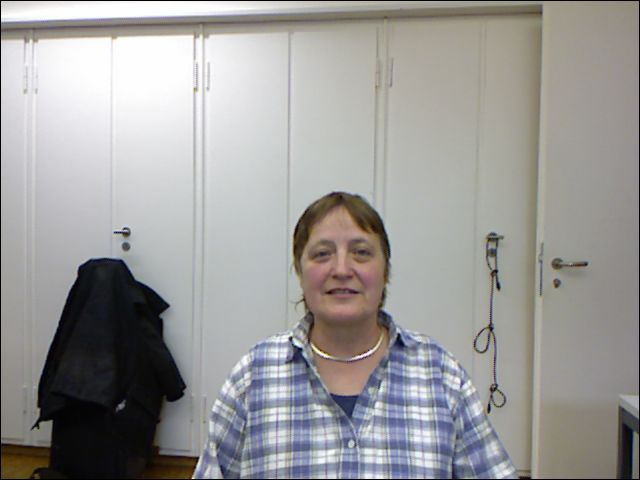

In [10]:
fname = (path/'01').ls().sorted()[2]
Image.open(fname)

In [11]:
# get a function that takes an image file and returns the corresponding pose file
img_files = get_image_files(path)

def img2pose(img_path):
    return Path(f'{str(img_path)[:-7]}pose.txt')

img2pose(img_files[0])

Path('22/frame_00163_pose.txt')

In [12]:
# inspect files
im = PILImage.create(img_files[0])
im.shape

(480, 640)

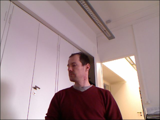

In [13]:
im.to_thumb(160)

In [14]:
cal = np.genfromtxt(path/'01'/'rgb.cal', skip_footer=6)
cal

array([[517.679,   0.   , 320.   ],
       [  0.   , 517.679, 240.5  ],
       [  0.   ,   0.   ,   1.   ]])

In [15]:
def get_ctr(f):
    ctr = np.genfromtxt(img2pose(f), skip_header=3)
    c1 = ctr[0] * cal[0][0]/ctr[2] + cal[0][2]
    c2 = ctr[1] * cal[1][1]/ctr[2] + cal[1][2]
    return tensor([c1,c2])

In [16]:
get_ctr(img_files[0])

tensor([311.6877, 268.2660])

That value represents the coordinates of the center of the head for the given image. `get_ctr` is therefore a good function to supply to `get_y` when building the data block. As we build the data block, we'll use `PointBlock` to inform fastai that the y values are coordinates of the input images. That way, fastai will ensure to properly apply any image transformations to those coordinates as well.

> This transformation of the center coordinates is important because the image transformations change the coordinates of the face center in the resulting image. So fastai has to know the starting position of the face and apply the same transformations to that point to arrive at the coords of the same center in the new image.

In [17]:
biwi = DataBlock(
    blocks=(ImageBlock, PointBlock),
    get_y=get_ctr,
    get_items=get_image_files,
    splitter=FuncSplitter(lambda o: o.parent.name=='13'),
    batch_tfms=aug_transforms(size=(240,320))
)

biwi.summary(path)

Setting-up type transforms pipelines
Found 15678 items
2 datasets of sizes 15193,485
Setting up Pipeline: PILBase.create
Setting up Pipeline: get_ctr -> TensorPoint.create

Building one sample
  Pipeline: PILBase.create
    starting from
      /root/.fastai/data/biwi_head_pose/22/frame_00163_rgb.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=640x480
  Pipeline: get_ctr -> TensorPoint.create
    starting from
      /root/.fastai/data/biwi_head_pose/22/frame_00163_rgb.jpg
    applying get_ctr gives
      tensor([311.6877, 268.2660])
    applying TensorPoint.create gives
      TensorPoint of size 1x2

Final sample: (PILImage mode=RGB size=640x480, TensorPoint([[311.6877, 268.2660]]))


Found 15678 items
2 datasets of sizes 15193,485
Setting up Pipeline: PILBase.create
Setting up Pipeline: get_ctr -> TensorPoint.create
Setting up after_item: Pipeline: PointScaler -> ToTensor
Setting up before_batch: Pipeline: 
Setting up after_batch: Pipeline: IntToFloatTensor -- {'div'

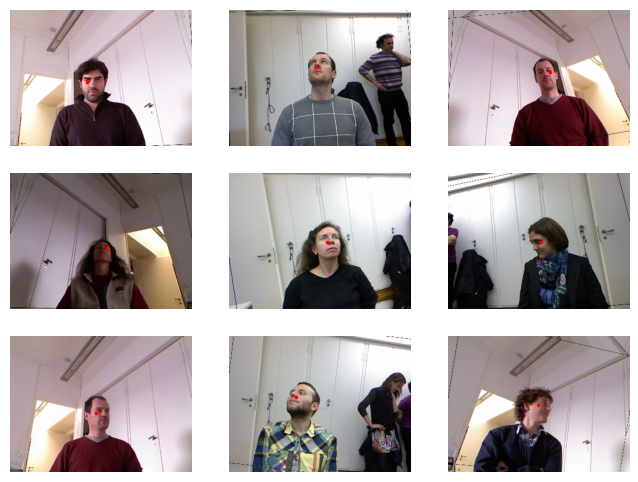

In [18]:
dls = biwi.dataloaders(path)
dls.show_batch(max_n=9, figsize=(8,6))

In [19]:
xb,yb = dls.one_batch()
xb.shape, yb.shape

(torch.Size([64, 3, 240, 320]), torch.Size([64, 1, 2]))

In [20]:
yb[0]

TensorPoint([[0.0432, 0.0600]], device='cuda:0')

In [21]:
learn = vision_learner(dls, resnet18, y_range=(-1, 1))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s] 


In [22]:
dls.loss_func

FlattenedLoss of MSELoss()

<div></div>

SuggestedLRs(valley=0.0014454397605732083)

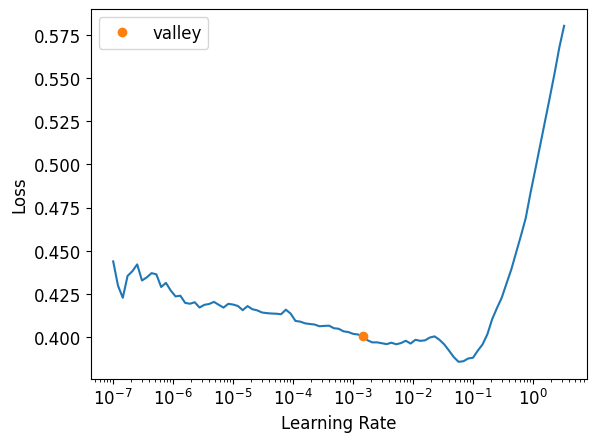

In [23]:
lr = learn.lr_find()
lr

In [24]:
learn.fine_tune(3, lr.valley)

epoch,train_loss,valid_loss,time
0,0.183252,0.022364,01:09


epoch,train_loss,valid_loss,time
0,0.029410,0.002857,01:30
1,0.005876,0.000254,01:30
2,0.003907,0.000790,01:33


The last validation loss value is `0.000790`. That's MSE, so the mean error of predicting coordinates is the square root of that number:

In [26]:
math.sqrt(0.000790)

0.028106938645110394

That means the predicted pixels will be off by 0.02px on average, which sounds quite accurate. This is a situation in which the loss function can actually also function as a metric, so once again, it's okay to buck the recommendations of theory because practice suggests otherwise.

Moreover, it's important to look at our results to see what the loss values look like in practice. The `.show_results()` method of the learner can do this for us. The values on the left are the real coords provided in the data, and those on the right are the model's predictions.

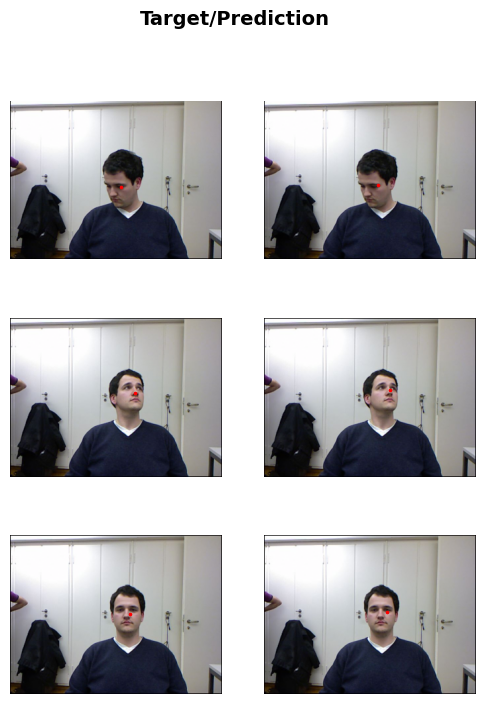

In [25]:
learn.show_results(ds_idx=1, nrows=3, figsize=(6,8))

Not bad at all.